# COVID-19 Literature Search Engine

## Overview

This project implements a full-text search engine over a corpus of COVID-19 scientific literature, using Python and the PyTerrier IR framework.

The pipeline covers three stages:

1. **Indexing** — Constructing an inverted index over the document corpus.
2. **Retrieval** — Querying the index using classical IR models: TF, TF-IDF, and BM25.
3. **Analysis** — Comparing model outputs and evaluating retrieval quality.

## Dependencies

| Library | Purpose |
|---|---|
| `pandas`, `numpy` | Data manipulation |
| `matplotlib` | Visualization |
| `nltk` | Text preprocessing — tokenization, stemming, stopword removal |
| `pyterrier` | Indexing and retrieval |

[PyTerrier](https://github.com/terrier-org/pyterrier) is an open-source Python library for building and experimenting with search engines, offering ready-to-use indexing and retrieval models.



#### Installation

In [73]:
!pip install python-terrier

In [74]:
### Importing Libraries
import pandas as pd
import os
import numpy as np
import pprint
from google.colab import files
import math
import matplotlib.pyplot as plt
import shutil
## Importing pyterrier:
import pyterrier as pt
if not pt.started():
  pt.init(tqdm='tqdm')

/tmp/ipykernel_156/3158286483.py:12: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


## Indexing

An index maps terms to the documents that contain them, enabling fast and efficient search.

Each document in the index requires two fields:

- **`docno`** — a unique identifier for the document.
- **`text`** — the content to be indexed and searched.


In [75]:
covid_csv = files.upload()

Saving covid_df.csv to covid_df (2).csv


In [76]:
# Load the dataset
covid_df = pd.read_csv("covid_df.csv")

# Convert all columns to string (required by PyTerrier)
covid_df = covid_df.astype('str')

# Build the two fields required for indexing
covid_df['docno'] = covid_df['doc_id']
covid_df['text'] = covid_df['Title'] + " "+  covid_df['Abstract']


covid_df.head(3)

,doc_id,Title,Abstract,Year,docno,text
0,37972180,"Humans are biocultural, science should be too.",COVID-19 is restructuring societies. Lonelines...,2023,37972180,"Humans are biocultural, science should be too...."
1,37972171,The responsibility turn,Lessons from the COVID-19 pandemic inspire a g...,2023,37972171,The responsibility turn Lessons from the COVID...
2,37943961,Correction is courageous.,In a year when disagreements over scientific m...,2023,37943961,Correction is courageous. In a year when disag...


PyTerrier provides several indexer classes depending on the input format. Since our dataset is a Pandas DataFrame, we use `DFIndexer`. For large or streaming datasets, `IterDictIndexer` is a more memory-efficient alternative.

Full list of supported indexers: [PyTerrier Indexing Docs](https://pyterrier.readthedocs.io/en/latest/terrier-indexing.html)

In [77]:
# Path where the index will be saved (created automatically by PyTerrier)
pt_index_path = './terrier_covid_index'

In [78]:
indexer_df = pt.index.DFIndexer(pt_index_path)

# First argument: text to index
# Second argument: metadata to store (accessible later via the Meta structure)
index_df = indexer_df.index(covid_df["text"], covid_df[['docno', 'Title', 'Abstract']] )


/tmp/ipykernel_156/1245397502.py:1: DeprecationWarning: Call to deprecated class DFIndexer. (use pt.terrier.IterDictIndexer().index(dataframe.to_dict(orient='records')) instead) -- Deprecated since version 0.11.0.
  indexer_df = pt.index.DFIndexer(pt_index_path)


In [79]:
index = pt.IndexFactory.of(index_df)
print(index.getCollectionStatistics())
index.getMetaIndex().getKeys()

Number of documents: 333
Number of terms: 3140
Number of postings: 16935
Number of fields: 0
Number of tokens: 23846
Field names: []
Positions:   false



['docno', 'Title', 'Abstract']

## Index Structures

The index exposes three core structures:

- **Meta index** — stores document-level metadata (docno, title, abstract).
- **Lexicon** — stores all indexed terms and their corpus-wide statistics.
- **Inverted index** — maps each term to the list of documents containing it.

In [80]:
## Index Structures
meta = index.getMetaIndex() #List of document identifiers.
lex = index.getLexicon() #List of indexed terms
inv = index.getInvertedIndex() #Inverted index, for each term lists the documents that contains it.

### Lexicon

Each term in the lexicon exposes the following statistics:

| Method | Description |
|---|---|
| `getDocumentFrequency()` | Number of documents containing the term |
| `getFrequency()` | Total occurrences across the corpus |
| `getMaxFrequencyInDocuments()` | Highest in-document frequency across all documents |
| `getTermId()` | Internal numeric ID of the term |

In [81]:
term="covid"
doc_freq=lex[term].getDocumentFrequency()
term_freq_total=lex[term].getFrequency()
max_term_freq=lex[term].getMaxFrequencyInDocuments()
term_id=lex[term].getTermId()
print("term occurs in", doc_freq, "documents")
print("term frequency in all documents is",term_freq_total)
print("maximum in-document term frequency is",max_term_freq)
print("id of the term is", term_id)

term occurs in 188 documents
term frequency in all documents is 329
maximum in-document term frequency is 8
id of the term is 21


In [82]:
# Terms can also be accessed by their numeric position in the lexicon
print(lex[21].getKey())      #term string
print(lex[21].getValue())    # term statistics


covid
term21 Nt=188 TF=329 maxTF=8 @{0 4669 5}


In the lexicon entry (e.g. `term21 Nt=188 TF=329 maxTF=8 @{0 4669 5}`):

- **Nt** — number of documents containing the term (document frequency)
- **TF** — total term occurrences across the corpus
- **maxTF** — highest frequency of the term in a single document
- **@{...}** — pointer to the term's postings in the inverted index

In [83]:
for id,term in enumerate(lex):
    if id>1000:
       print(term.getKey(), term.getValue())
    if id==1010: break

effort term671 Nt=16 TF=17 maxTF=2 @{0 6173 4}
eidd term1818 Nt=1 TF=1 maxTF=1 @{0 6190 5}
eightfold term3069 Nt=1 TF=1 maxTF=1 @{0 6192 5}
elderli term2265 Nt=1 TF=1 maxTF=1 @{0 6194 7}
elect term2706 Nt=1 TF=1 maxTF=1 @{0 6196 7}
electron term1323 Nt=26 TF=26 maxTF=1 @{0 6199 1}
element term2076 Nt=1 TF=1 maxTF=1 @{0 6219 7}
elementari term2298 Nt=1 TF=1 maxTF=1 @{0 6221 7}
eletron term2951 Nt=1 TF=1 maxTF=1 @{0 6223 7}
elicit term902 Nt=19 TF=32 maxTF=4 @{0 6226 1}


- Using a term we can find which documents have this specific term accessing into the inverted index.


<figure>
<!-- <center> -->
<img src='https://drive.google.com/uc?id=1Cu4l2t7xnXrWh1Fw8SkT26H5IipRb-Pa' />
<figcaption>  </figcaption>
<!-- </center> -->
</figure>


In [84]:
def documents_with_term(term):
    input=lex[term]
    documents=[]
    for posting in inv.getPostings(input):
        doc_ID=posting.getId()
        term_freq=posting.getFrequency()
        docno=meta.getItem("docno",doc_ID)
        doc_title=meta.getItem("Title",doc_ID)
        doc_abstract=meta.getItem("Abstract",doc_ID)
        document={'docno': docno, 'title': doc_title, 'abstract': doc_abstract, 'term_frequency': term_freq}
        documents.append(document)
    return documents

In [85]:
term="campaign"
docs_campaign=documents_with_term(term)
pprint.pprint(docs_campaign)
doc_freq_campaign =lex[term].getDocumentFrequency()
print(doc_freq_campaign,"documents contain this term")

[{'abstract': 'We report the results of the COVID Moonshot, a fully '
              'open-science, crowdsourced, and structure-enabled drug '
              'discovery campaign targeting the severe acute respiratory '
              'syndrome coronavirus 2 (SARS-CoV-2) main protease. We '
              'discovered a noncovalent, nonpeptidic inhibitor scaffold with '
              'lead-like properties that is differentiated from current main '
              'protease inhibitors. Our approach leveraged crowdsourcing, '
              'machine learning, exascale molecular simulations, and '
              'high-throughput structural biology and chemistry. We generated '
              'a detailed map of the structural plasticity of the SARS-CoV-2 '
              'main protease, extensive structure-activity relationships for '
              'multiple chemotypes, and a wealth of biochemical activity data. '
              'All compound designs (>18,000 designs), crystallographic data '
         

### TF-IDF Scoring

TF-IDF weighs a term's importance in a document relative to the whole corpus:

- **TF** (Term Frequency) — how often the term appears in the document
- **IDF** (Inverse Document Frequency) — `log(N / DF)`, where N is the corpus size and DF is the number of documents containing the term

Terms that appear frequently in a document but rarely across the corpus receive a higher score.

In [86]:
def documents_with_term_tfidf(term):
    input=lex[term]
    docs_tfidf=[]
    for posting in inv.getPostings(input):
        TF= posting.getFrequency()
        DF= lex[term].getDocumentFrequency()
        num_corpus=len(covid_df)
        IDF=math.log(num_corpus/DF)
        TF_IDF=TF*IDF
        doc_ID=posting.getId()
        docno=meta.getItem("docno",doc_ID)
        doc_tfidf={'doc_number': docno, 'TF_IDF': TF_IDF}
        docs_tfidf.append(doc_tfidf)
    return docs_tfidf

In [87]:
term="campaign"
tfidf_docs_campaign=documents_with_term_tfidf(term)
pprint.pprint(tfidf_docs_campaign)

[{'TF_IDF': 9.419060402624668, 'doc_number': '37943932'},
 {'TF_IDF': 4.709530201312334, 'doc_number': '35133177'},
 {'TF_IDF': 4.709530201312334, 'doc_number': '33758017'}]


Document `37943932` scores highest for the term *"campaign"*, meaning it contains the term more frequently relative to its rarity in the corpus. The other two documents share an equal score, indicating the term appears the same number of times in each.

### Identifying the Most Relevant Document

The function below computes TF-IDF scores for all documents containing a given term and returns the one with the highest score — the document where the term is most discriminative.



In [88]:
def get_highest_tfidf(term):
    tfidf=documents_with_term_tfidf(term)
    tfidf_dataframe= pd.DataFrame(tfidf)
    max_tfidf=max(tfidf_dataframe['TF_IDF'])
    docid_max=tfidf_dataframe.loc[tfidf_dataframe['TF_IDF']==max_tfidf,'doc_number']
    docid_max_tfidf=docid_max.tolist()
    result=print("highest tf.idf value for the term is", max_tfidf , "for document(s)",docid_max_tfidf)
    return result, tfidf_dataframe['doc_number'], tfidf_dataframe['TF_IDF']

highest tf.idf value for the term is 5.02461124795223 for document(s) ['36264829', '34812653', '32669297']


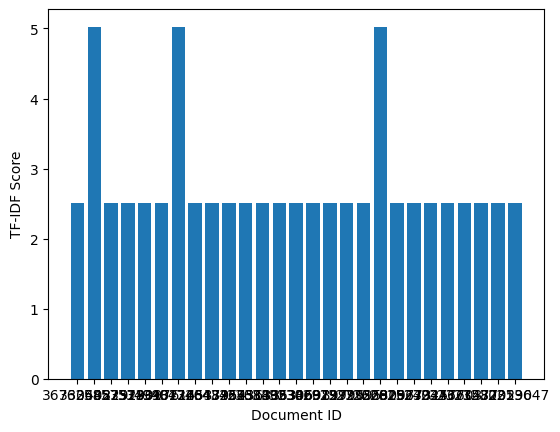

In [89]:
term="clinic"
result, doc_ids, tfidf_scores = get_highest_tfidf(term)
plt.bar(x=doc_ids, height=tfidf_scores)
plt.xlabel('Document ID')
plt.ylabel('TF-IDF Score')
plt.show()

Most documents share a similar TF-IDF score, meaning the term appears once in each. The few documents with noticeably higher scores contain the term multiple times, making them stronger candidates for relevance.

### Text Preprocessing

Querying the term `"infection"` directly returns no results — because PyTerrier applies **stemming** during indexing, storing `"infect"` instead of `"infection"`. Queries must go through the same preprocessing pipeline to match indexed terms correctly.

The `string2list` function replicates this pipeline: tokenization → stemming → stopword removal.



In [90]:
import nltk
from nltk import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = stopwords.words()

stemer = PorterStemmer()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [91]:
def string2list(words):

  stem_list=[]
  tokens=word_tokenize(words)
  for token in tokens:
      stem=stemer.stem(token)
      if stem not in stop_words:
         stem_list.append(stem)
  return stem_list

In [92]:
word="infection"
term=string2list("infection")
print(term)

['infect']


In [93]:
result, doc_ids, tfidf_scores = get_highest_tfidf("infect")

highest tf.idf value for the term is 8.436418390992634 for document(s) ['32179701']


## Query Processing

To retrieve documents for a query, each query term goes through the same preprocessing pipeline used during indexing (tokenization, stemming, stopword removal). We then look up each stemmed term in the inverted index and return all matching documents ranked by TF-IDF score.


In [94]:
def get_documents_query(query):
    documents=[]
    query_list=string2list(query)
    covid_df['stem_text']=covid_df.text.apply(lambda text: string2list(text))
    flatten=[item for sublist in covid_df['stem_text'] for item in sublist]
    for term in query_list:
        if term in flatten:
           input=lex.getLexiconEntry(term)
           for posting in inv.getPostings(input):
               doc_ID=posting.getId()
               docno=meta.getItem("docno",doc_ID)
               TF= posting.getFrequency()
               DF= lex[term].getDocumentFrequency()
               num_corpus=len(covid_df)
               IDF=math.log(num_corpus/DF)
               TF_IDF=TF*IDF
               document={'docno': docno,'TF_IDF': TF_IDF, 'term': term}
               documents.append(document)
               docs_df=pd.DataFrame(documents)
        else: print("term ",{term},"was not found in the corpus")
    return docs_df

Define a query and show the retrieved documents.
- **Question** Which of the retrieved documents is the most relevant for your query?  

In [95]:
get_documents_query('effect of covid on lung in iran')

term  {'iran'} was not found in the corpus


,docno,TF_IDF,term
0,37410823,1.819158,effect
1,37289888,1.819158,effect
2,36074833,5.457475,effect
3,36007042,1.819158,effect
4,35771934,1.819158,effect
...,...,...,...
251,32527928,12.676341,lung
252,32527925,6.338170,lung
253,32404477,3.169085,lung
254,32358202,3.169085,lung


The query returns 256 matching documents across three stemmed terms: `"effect"`, `"covid"`, and `"lung"` — with `"iran"` absent from the corpus. Results are listed per term; document `32527928` ranks highest overall with a TF-IDF of 12.67 for `"lung"`, making it the strongest candidate for relevance to this query.



## Retrieval

So far we retrieved documents by matching individual terms. A proper search engine ranks results using a **similarity function** that scores each document against the full query.

PyTerrier's `BatchRetrieve` provides built-in implementations of three classical ranking models:

| Model | Description |
|---|---|
| **TF** | Ranks by raw term frequency |
| **TF-IDF** | Weighs frequency against term rarity across the corpus |
| **BM25** | Extends TF-IDF with document length normalization — generally the strongest baseline |

In [96]:
tf_idf = pt.BatchRetrieve(index, wmodel="TF_IDF", metadata=["Title", "Abstract"])
tf_model=pt.BatchRetrieve(index, wmodel="Tf", metadata=["Title", "Abstract"])
bm25 = pt.BatchRetrieve(index, wmodel="BM25", metadata=["Title", "Abstract"])

/tmp/ipykernel_156/2915288200.py:1: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  tf_idf = pt.BatchRetrieve(index, wmodel="TF_IDF", metadata=["Title", "Abstract"])
/tmp/ipykernel_156/2915288200.py:2: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  tf_model=pt.BatchRetrieve(index, wmodel="Tf", metadata=["Title", "Abstract"])
/tmp/ipykernel_156/2915288200.py:3: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  bm25 = pt.BatchRetrieve(index, wmodel="BM25", metadata=["Title", "Abstract"])


In [97]:
query1 = "covid"
tf_idf_result   = tf_idf.search(query1)
tf_model_result = tf_model.search(query1)
bm25_result     = bm25.search(query1)

In [98]:
tf_idf_result.head(3)

,qid,docid,Title,Abstract,rank,score,query
0,1,67,COVID-19 and children.,There has been substantial research on adult C...,0,1.452366,covid
1,1,51,COVID-19 vaccination and menstruation.,COVID-19 vaccination causes small changes to m...,1,1.432712,covid
2,1,108,The immunology and immunopathology of COVID-19.,Considerable research effort has been made wor...,2,1.429648,covid


In [99]:
tf_model_result.head(3)

,qid,docid,Title,Abstract,rank,score,query
0,1,67,COVID-19 and children.,There has been substantial research on adult C...,0,8.0,covid
1,1,139,COVID mortality in India: National survey data...,India’s national COVID death totals remain und...,1,8.0,covid
2,1,108,The immunology and immunopathology of COVID-19.,Considerable research effort has been made wor...,2,6.0,covid


In [100]:
bm25_result.head(3)

,qid,docid,Title,Abstract,rank,score,query
0,1,241,Mosaic nanoparticles elicit cross-reactive imm...,Protection against severe acute respiratory sy...,0,-0.281314,covid
1,1,123,Broad anti-SARS-CoV-2 antibody immunity induce...,Heterologous prime-boost immunization strategi...,1,-0.284992,covid
2,1,202,Senolytics reduce coronavirus-related mortalit...,The COVID-19 pandemic has revealed the pronoun...,2,-0.286240,covid


In [101]:
query2 = "clinical trails in covid"
tf_idf_result   = tf_idf.search(query2)
tf_model_result = tf_model.search(query2)
bm25_result     = bm25.search(query2)

In [102]:
tf_idf_result.head(3)

,qid,docid,Title,Abstract,rank,score,query
0,1,37,Protein decoys may battle COVID-19 and more.,Drugs designed to resemble viruses' cellular t...,0,4.198137,clinical trails in covid
1,1,153,Immune correlates analysis of the mRNA-1273 CO...,In the coronavirus efficacy (COVE) phase 3 cli...,1,3.844394,clinical trails in covid
2,1,289,Deep immune profiling of COVID-19 patients rev...,Coronavirus disease 2019 (COVID-19) is current...,2,3.803648,clinical trails in covid


In [103]:
tf_model_result.head(3)

,qid,docid,Title,Abstract,rank,score,query
0,1,67,COVID-19 and children.,There has been substantial research on adult C...,0,8.0,clinical trails in covid
1,1,139,COVID mortality in India: National survey data...,India’s national COVID death totals remain und...,1,8.0,clinical trails in covid
2,1,153,Immune correlates analysis of the mRNA-1273 CO...,In the coronavirus efficacy (COVE) phase 3 cli...,2,7.0,clinical trails in covid


In [104]:
bm25_result.head(3)

,qid,docid,Title,Abstract,rank,score,query
0,1,37,Protein decoys may battle COVID-19 and more.,Drugs designed to resemble viruses' cellular t...,0,4.588876,clinical trails in covid
1,1,55,Imprinted antibody responses against SARS-CoV-...,Severe acute respiratory syndrome coronavirus ...,1,4.127941,clinical trails in covid
2,1,289,Deep immune profiling of COVID-19 patients rev...,Coronavirus disease 2019 (COVID-19) is current...,2,3.725332,clinical trails in covid


Each row in the results contains the document ID, title, abstract, rank, and relevance score.
Comparing the three models on the top 3 results:

- **TF** ranks by how many times the term appears — longer documents tend to score higher simply because they contain more words.
- **TF-IDF** reduces the importance of terms that appear in most documents, since they carry little discriminative value.
- **BM25** goes further by also accounting for document length, making it the most balanced and widely used model of the three.

### Query 1: `"covid"`

For a single, corpus-wide common term, all three models return broadly similar documents. TF and TF-IDF agree on the top result (*"COVID-19 and children"*), while BM25 produces negative scores — expected behaviour when a term appears in nearly every document, causing its length normalization to penalize rather than reward matches.

### Query 2: `"clinical trials in covid"`

With a more specific multi-term query, the differences between models become clear:

- **TF** ignores term rarity and ranks *"COVID-19 and children"* first — a general article that simply contains many of the query terms.
- **TF-IDF** and **BM25** both rank *"Protein decoys may battle COVID-19"* first, rewarding documents where the less common terms like `"clinical"` and `"trial"` carry more weight.

TF-IDF and BM25 produce more relevant results for specific queries, while TF is unreliable when query terms vary in specificity.

In [105]:
# Inspect full document content for the top 3 results
tf_idf_result_dict = tf_idf_result.to_dict(orient="records")
tf_idf_result_dict[:3]

[{'qid': '1',
  'docid': 37,
  'Title': 'Protein decoys may battle COVID-19 and more.',
  'Abstract': "Drugs designed to resemble viruses' cellular targets move into clinical trials.",
  'rank': 0,
  'score': 4.1981366706062735,
  'query': 'clinical trails in covid'},
 {'qid': '1',
  'docid': 153,
  'Title': 'Immune correlates analysis of the mRNA-1273 COVID-19 vaccine efficacy clinical trial.',
  'Abstract': 'In the coronavirus efficacy (COVE) phase 3 clinical trial, vaccine recipients were assessed for neutralizing and binding antibodies as correlates of risk for COVID-19 disease and as correlates of protection. These immune markers were measured at the time of second vaccination and 4 weeks later, with values reported in standardized World Health Organization international units. All markers were inversely associated with COVID-19 risk and directly associated with vaccine efficacy. Vaccine recipients with postvaccination 50% neutralization titers 10, 100, and 1000 had estimated vacc

Converting results to a dictionary allows inspection of the full document content. The top 3 TF-IDF results for `"clinical trials in covid"` are all genuinely relevant:

- **Rank 0** — an article about protein-based drugs entering clinical trials against COVID-19
- **Rank 1** — a study on immune correlates from the mRNA-1273 vaccine clinical trial
- **Rank 2** — a deep immune profiling study identifying patient immunotypes with therapeutic implications

All three are topically specific and directly relevant to the query, confirming that TF-IDF effectively surfaces focused scientific literature for multi-term queries.

In [106]:
# Clean up the index from disk
shutil.rmtree('./terrier_covid_index')

## Conclusion

This project covered the full pipeline of a text-based search engine over a COVID-19 scientific corpus — from building an inverted index to querying it with three classical retrieval models.

Starting from raw data, we built an inverted index and explored its core structures: the lexicon, postings list, and metadata store. We then implemented TF-IDF from scratch before switching to PyTerrier's built-in models to compare TF, TF-IDF, and BM25 at scale.

The key takeaway is that model choice has little impact on simple single-term queries, but becomes significant for specific multi-term queries where TF-IDF and BM25 consistently surface more relevant results than raw TF. BM25 remains the strongest baseline, as it accounts for both term rarity and document length.

Overall, this pipeline reflects the fundamental building blocks behind modern search engines, and the same principles apply to larger, production-scale retrieval systems.